In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# 导入数据
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

#### 1、数据EDA

In [3]:
# 查看数据基本情况
print('数据前五行：')
display(train.head())

print('\n数据类型：')
display(train.info())

print('\n数据维度：')
print(train.shape)

print('\n列名：')
display(train.columns)

print('\n统计摘要：')
display(train.describe())

数据前五行：


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,187,37,125591,2013-08-08,IN,500/1000,1000,1412.06,5000000,450947,...,?,57700,5770,5770,46160,Nissan,Maxima,2000,0,NaN
1,243,44,967713,1997-12-25,IL,250/500,500,809.11,0,600208,...,YES,51400,5140,10280,35980,Honda,Civic,1996,0,NaN
2,24,33,649082,1996-01-19,IL,500/1000,1000,1922.84,0,431277,...,NO,46800,4680,9360,32760,Jeep,Wrangler,2002,0,NaN
3,215,42,519312,2008-10-28,OH,500/1000,500,1848.81,0,435489,...,YES,68520,11420,5710,51390,Suburu,Legacy,2003,1,NaN
4,85,30,190588,2001-12-09,OH,100/300,1000,796.35,0,614166,...,YES,58960,5360,10720,42880,Ford,F150,2004,0,NaN



数据类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           700 non-null    int64  
 1   age                          700 non-null    int64  
 2   policy_number                700 non-null    int64  
 3   policy_bind_date             700 non-null    object 
 4   policy_state                 700 non-null    object 
 5   policy_csl                   700 non-null    object 
 6   policy_deductable            700 non-null    int64  
 7   policy_annual_premium        700 non-null    float64
 8   umbrella_limit               700 non-null    int64  
 9   insured_zip                  700 non-null    int64  
 10  insured_sex                  700 non-null    object 
 11  insured_education_level      700 non-null    object 
 12  insured_occupation           700 non-null    object 
 13  insured_hobbi

None


数据维度：
(700, 40)

列名：


Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')


统计摘要：


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,fraud_reported,_c39
count,700.000000,700.000000,700.000000,700.000000,700.000000,7.000000e+02,700.000000,700.000000,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,0.0
mean,205.894286,39.105714,549242.077143,1147.857143,1245.976271,1.100000e+06,501432.612857,25804.857143,-26228.00000,11.642857,1.870000,0.994286,1.477143,52475.685714,7463.257143,7324.142857,37688.285714,2004.931429,0.258571,NaN
std,116.018709,9.166258,258480.463210,611.579706,248.310901,2.282922e+06,72210.251502,28043.400441,28422.99164,6.964524,1.035265,0.818227,1.113472,26115.219702,4890.609140,4778.111003,18695.686555,5.983371,0.438163,NaN
min,0.000000,20.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.00000,0.000000,1.000000,0.000000,0.000000,100.000000,0.000000,0.000000,70.000000,1995.000000,0.000000,NaN
25%,114.000000,32.000000,343282.750000,500.000000,1077.460000,0.000000e+00,447978.250000,0.000000,-51275.00000,5.000000,1.000000,0.000000,0.000000,41662.500000,4265.000000,4420.000000,29872.500000,2000.000000,0.000000,NaN
50%,202.000000,38.000000,536799.000000,1000.000000,1252.280000,0.000000e+00,466242.000000,11550.000000,-15650.00000,12.000000,1.000000,1.000000,1.000000,57710.000000,6820.000000,6685.000000,41760.000000,2005.000000,0.000000,NaN
75%,279.000000,45.000000,757918.000000,2000.000000,1402.757500,0.000000e+00,603946.000000,51400.000000,0.00000,17.000000,3.000000,2.000000,2.000000,70072.500000,11235.000000,10825.000000,50417.500000,2010.000000,1.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.00000,23.000000,4.000000,2.000000,3.000000,114920.000000,21450.000000,23670.000000,79560.000000,2015.000000,1.000000,NaN


fraud_reported
0    0.741429
1    0.258571
Name: proportion, dtype: float64


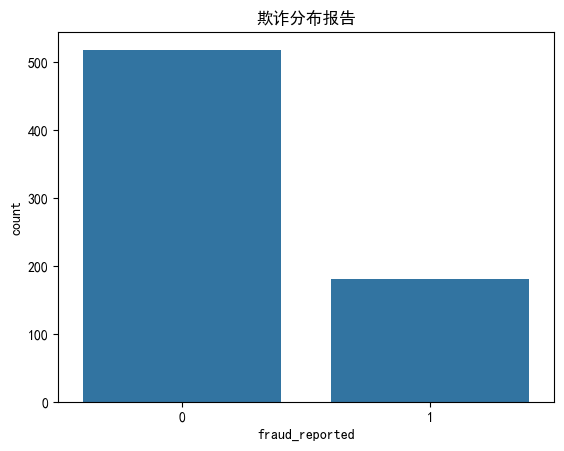

In [4]:
# 二分类问题
# 查看样本平衡性
print(train['fraud_reported'].value_counts(normalize = True))
sns.countplot(x = 'fraud_reported',data = train)
plt.title('欺诈分布报告')
plt.rcParams['font.sans-serif'] = 'Simhei'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# from pandas_profiling import ProfileReport
# ProfileReport有版本冲突

In [6]:
print(train['fraud_reported'].value_counts(dropna=False))
print(train['fraud_reported'].unique())

fraud_reported
0    519
1    181
Name: count, dtype: int64
[0 1]


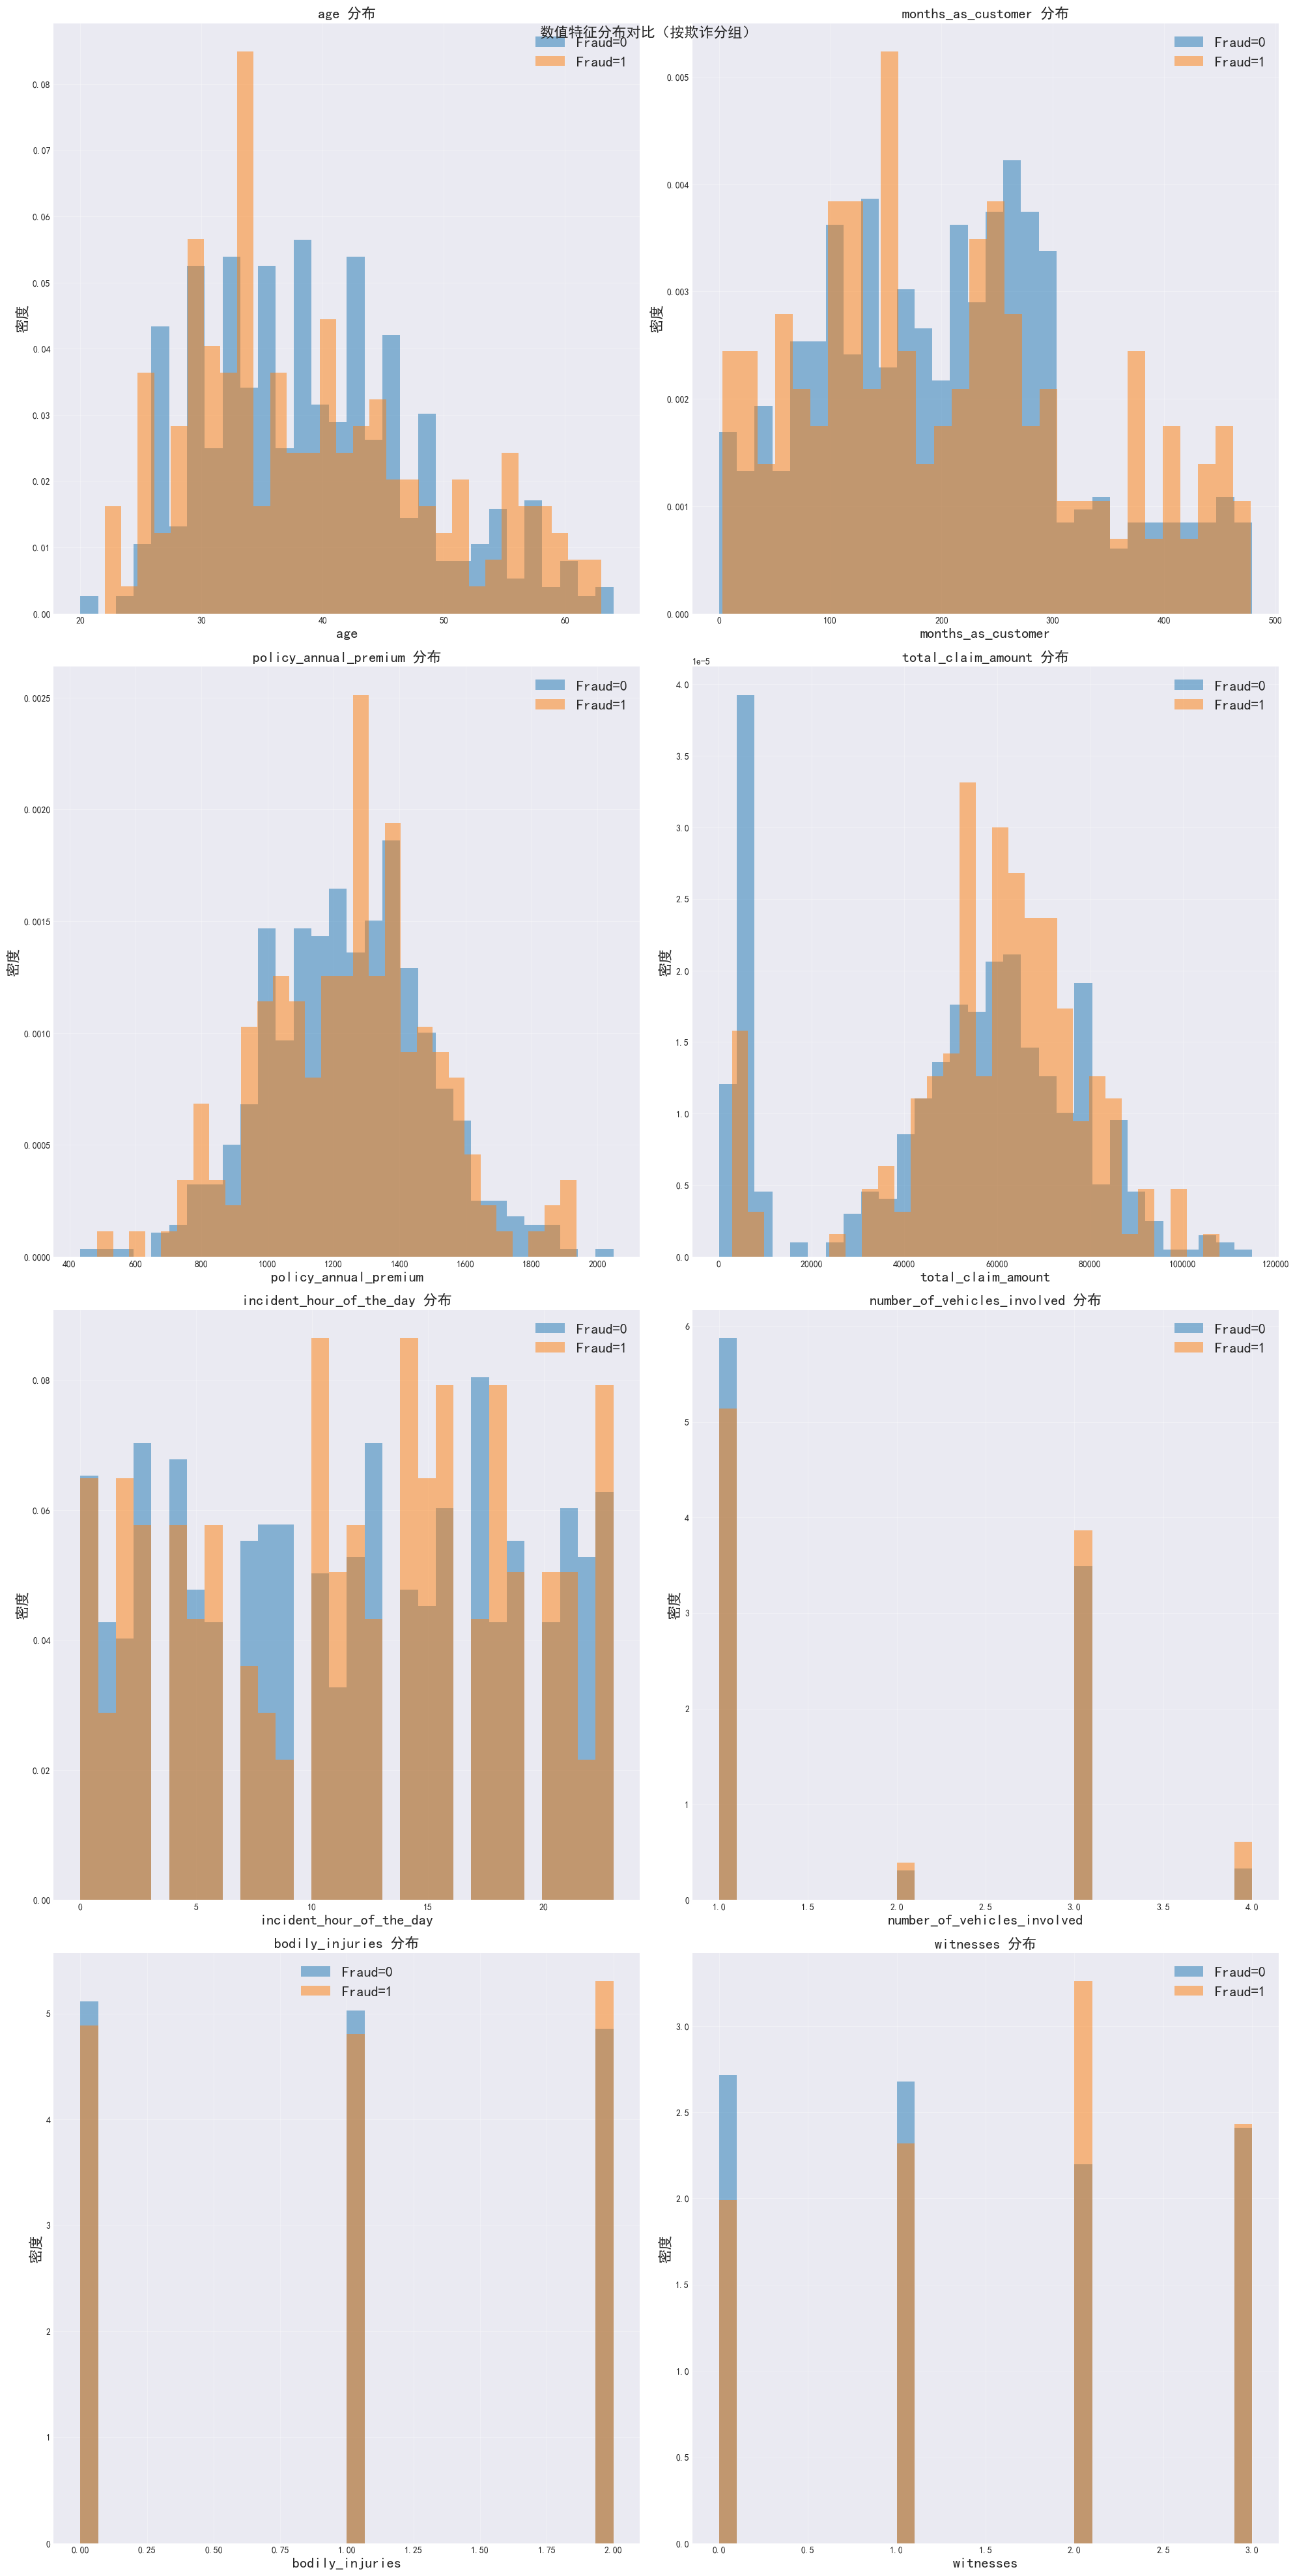

In [7]:
# 数值特征分布
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.sans-serif'] = 'Simhei'
plt.rcParams['axes.unicode_minus'] = False
# 选择主要数值特征
numeric_features = ['age', 'months_as_customer', 'policy_annual_premium', 
                   'total_claim_amount', 'incident_hour_of_the_day', 
                   'number_of_vehicles_involved', 'bodily_injuries', 'witnesses']

# 创建分布图（按欺诈分组）
fig, axes = plt.subplots(4, 2, figsize=(20, 40))
axes = axes.ravel()

for i, feature in enumerate(numeric_features):
    # 直方图
    for j, fraud_value in enumerate([0, 1]):
        subset = train[train['fraud_reported'] == fraud_value]
        axes[i].hist(subset[feature].dropna(), bins=30, alpha=0.5,
                    label=f'Fraud={fraud_value}', density=True)
    axes[i].set_title(f'{feature} 分布', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(feature,fontsize=16)
    axes[i].set_ylabel('密度',fontsize=16)
    axes[i].legend(fontsize=16)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('数值特征分布对比（按欺诈分组）', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('numeric_distributions.png', dpi=300, bbox_inches='tight')

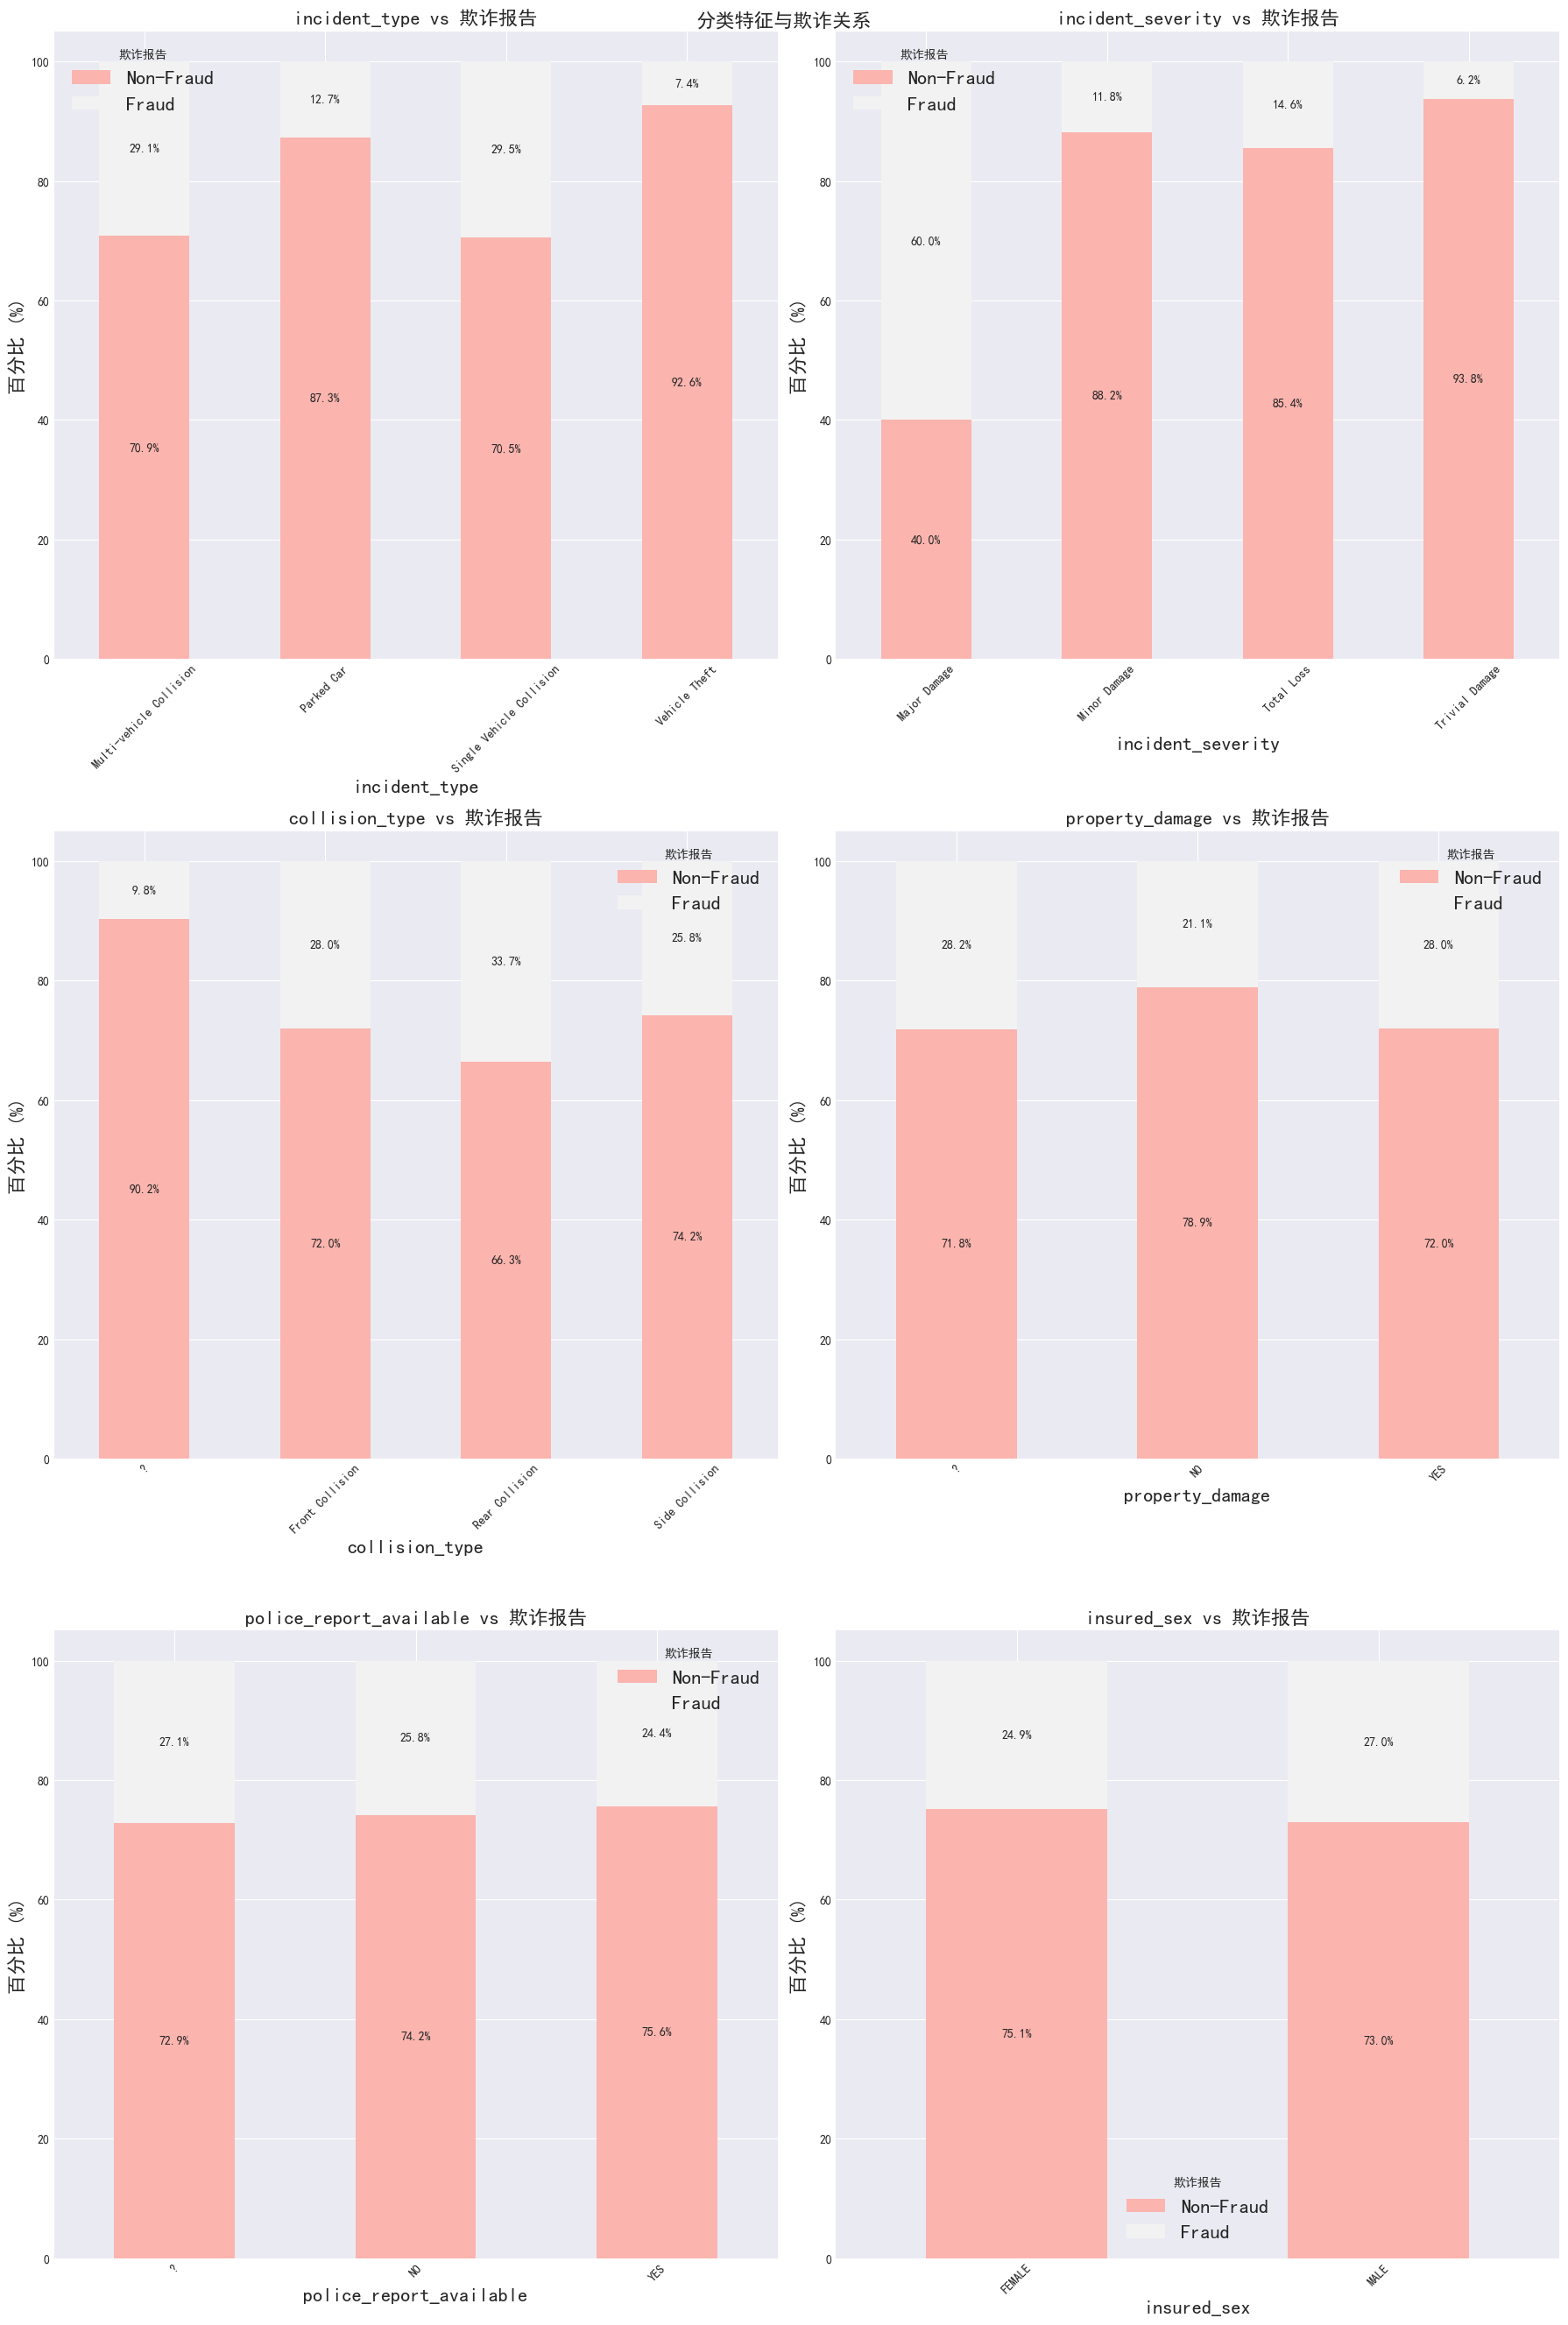

In [8]:
# 选择重要分类特征
categorical_features = ['incident_type', 'incident_severity', 'collision_type',
                       'property_damage', 'police_report_available', 'insured_sex']

fig, axes = plt.subplots(3, 2, figsize=(18, 27))
axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    # 计算百分比
    cross_tab = pd.crosstab(train[feature], train['fraud_reported'], normalize='index') * 100
    
    # 绘制堆叠条形图
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], colormap='Pastel1')
    axes[i].set_title(f'{feature} vs 欺诈报告', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(feature,fontsize=16)
    axes[i].set_ylabel('百分比 (%)',fontsize=16)
    axes[i].legend(title='欺诈报告', labels=['Non-Fraud', 'Fraud'],fontsize=16)
    axes[i].tick_params(axis='x', rotation=45)
    
    # 在柱子上添加数值标签
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', label_type='center')

plt.suptitle('分类特征与欺诈关系', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('categorical_analysis.png', dpi=300, bbox_inches='tight')

#### 2.特征工程

In [9]:
# 缺失值处理
miss_count = train.isnull().sum()
miss_df = pd.DataFrame({'缺失数量':miss_count})
display(miss_df)

,缺失数量
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [10]:
# 去除_c39列
train2 = train.drop('_c39', axis = 1)
test2 = test.drop('_c39', axis = 1)

In [11]:
# test2['authorities_contacted'].dtype
# 'authorities_contacted'是object类型，不方便使用众数预测
# 可以使用众数填充，或建模预测填充

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [13]:
# 寻找与authorities_contacted相关的特征
# 因为数据有数值类型有object类型，先进行编码处理
train2_copy = train2.copy()
le = LabelEncoder()
train2_copy['authorities_contacted_encoded'] = le.fit_transform(train2_copy['authorities_contacted'].astype(str))
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("authorities_contacted 编码映射:")
print(mapping)

authorities_contacted 编码映射:
{'Ambulance': np.int64(0), 'Fire': np.int64(1), 'Other': np.int64(2), 'Police': np.int64(3), 'nan': np.int64(4)}


In [14]:
# 选择数值型列
numeric_cols = train2_copy.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n数值型特征数量: {len(numeric_cols)}")

# 计算与 authorities_contacted 的相关系数
correlations = train2_copy[numeric_cols].corr()['authorities_contacted_encoded'].sort_values(ascending=False)

print("\n与 authorities_contacted 相关性最强的数值特征:")
print(correlations)


数值型特征数量: 20

与 authorities_contacted 相关性最强的数值特征:
authorities_contacted_encoded    1.000000
policy_number                    0.078165
capital-loss                     0.042687
age                              0.031650
witnesses                        0.019198
months_as_customer               0.018870
auto_year                        0.016310
umbrella_limit                   0.014852
bodily_injuries                  0.007213
capital-gains                    0.001102
policy_deductable               -0.013068
insured_zip                     -0.015701
policy_annual_premium           -0.057201
fraud_reported                  -0.122023
incident_hour_of_the_day        -0.163234
number_of_vehicles_involved     -0.205902
property_claim                  -0.356378
injury_claim                    -0.369570
total_claim_amount              -0.477243
vehicle_claim                   -0.478885
Name: authorities_contacted_encoded, dtype: float64


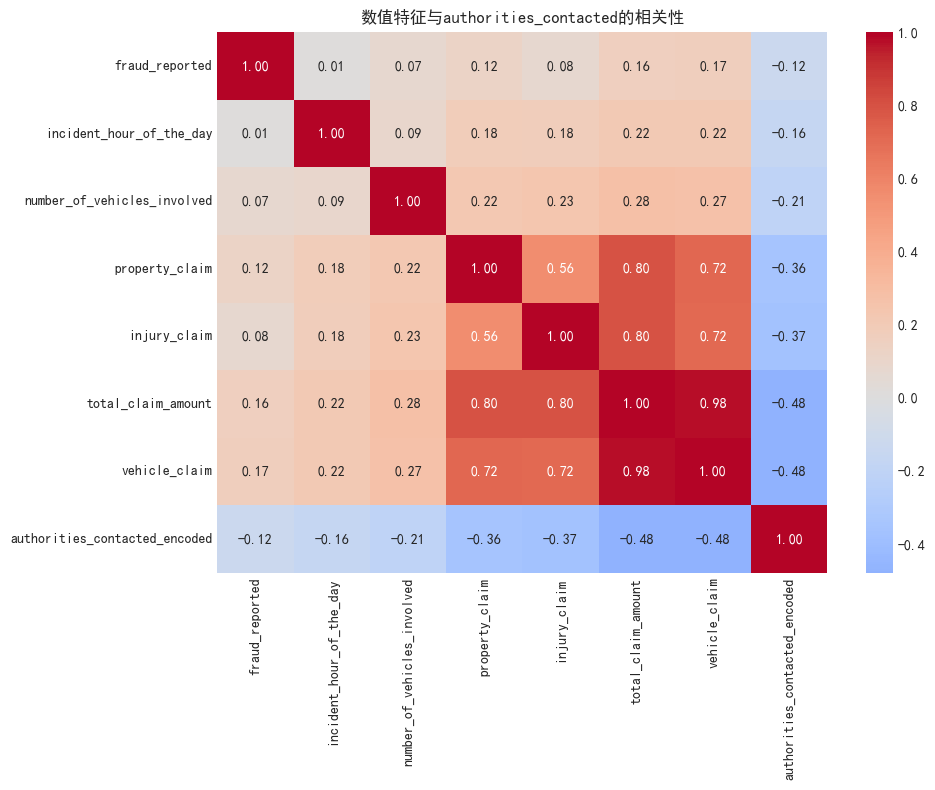

In [15]:
# 绘制热力图（只显示与authorities_contacted相关的部分）
plt.figure(figsize=(10, 8))

# 选择与authorities_contacted相关性较高的特征（|corr| > 0.1）
high_corr_features = correlations[abs(correlations) > 0.1].index.tolist()
if 'authorities_contacted_encoded' in high_corr_features:
    high_corr_features.remove('authorities_contacted_encoded')

if len(high_corr_features) > 0:
    # 计算这些特征的相关性矩阵
    corr_matrix = train2_copy[high_corr_features + ['authorities_contacted_encoded']].corr()
    
    # 绘制热力图
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('数值特征与authorities_contacted的相关性')
    plt.tight_layout()
else:
    print("没有相关性较高的数值特征")

In [16]:
from scipy import stats


分类型特征:
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']

分类特征与authorities_contacted的关联强度 (Cramer's V):
collision_type             0.279712
incident_type              0.277915
incident_severity          0.216213
auto_make                  0.085509
insured_sex                0.068662
policy_csl                 0.051950
police_report_available    0.047290
incident_city              0.037764
auto_model                 0.037682
insured_relationship       0.011267
policy_bind_date           0.000000
policy_state               0.000000
insured_education_level    0.000000
insured_occupation         0.000000
insured_hobbies            0.000000
incident_date              0.000000
incident_

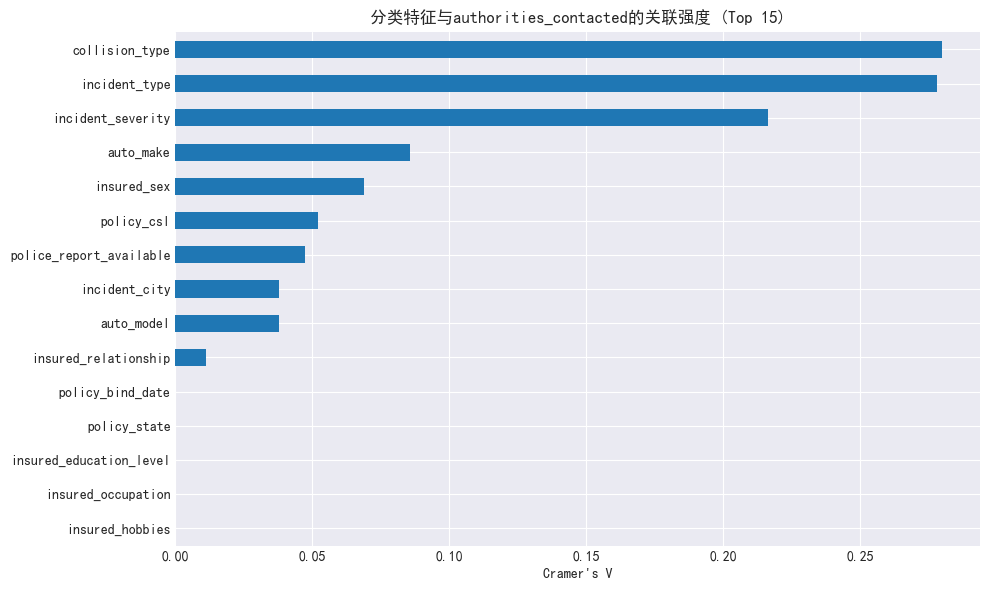

In [17]:
categorical_cols = train2_copy.select_dtypes(include=['object']).columns.tolist()
if 'authorities_contacted' in categorical_cols:
    categorical_cols.remove('authorities_contacted')  # 移除目标列本身
if '_c39' in categorical_cols:  # 移除可能的无用列
    categorical_cols.remove('_c39')

print("\n分类型特征:")
print(categorical_cols)

# 定义Cramer's V函数
def cramers_v(confusion_matrix):
    """计算Cramer's V统计量（修复版，处理除零错误）"""
    try:
        # 计算卡方值
        chi2 = stats.chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        
        # 计算phi2
        phi2 = chi2 / n
        
        # 获取矩阵维度
        r, k = confusion_matrix.shape
        
        # 计算修正后的phi2
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        
        # 计算分母，避免除零
        denominator = min((kcorr-1), (rcorr-1))
        if denominator <= 0 or np.isnan(denominator):
            return 0.0
        
        result = np.sqrt(phi2corr / denominator)
        
        # 处理可能的NaN或无穷大
        if np.isnan(result) or np.isinf(result):
            return 0.0
            
        return min(result, 1.0)  # Cramer's V应该在0-1之间
        
    except:
        # 如果计算过程中出现任何错误，返回0
        return 0.0

# 计算每个分类特征与authorities_contacted的Cramer's V值
cramers_v_results = {}

for col in categorical_cols:
    # 创建混淆矩阵
    contingency_table = pd.crosstab(train2_copy[col], train2_copy['authorities_contacted'])
    cramers_v_results[col] = cramers_v(contingency_table)

# 转换为Series并排序
cramers_v_series = pd.Series(cramers_v_results).sort_values(ascending=False)

print("\n分类特征与authorities_contacted的关联强度 (Cramer's V):")
print(cramers_v_series)

# 可视化Cramer's V结果
plt.figure(figsize=(10, 6))
cramers_v_series.head(15).plot(kind='barh')
plt.xlabel("Cramer's V")
plt.title('分类特征与authorities_contacted的关联强度 (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()

In [18]:
# type(high_corr_features)
# 获取相关性较高的数值型特征与object类型特征名称
threshold = 0.05
high_corr_columns = cramers_v_series[cramers_v_series > threshold].index.tolist()

feature_cols = high_corr_features + high_corr_columns
print(feature_cols)

['fraud_reported', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_claim', 'injury_claim', 'total_claim_amount', 'vehicle_claim', 'collision_type', 'incident_type', 'incident_severity', 'auto_make', 'insured_sex', 'policy_csl']


In [19]:
# 使用建模预测，先准备数据
miss_mask = train2['authorities_contacted'].isnull()
train2_data = train2[~miss_mask].copy()
predict_data = train2[miss_mask].copy()

In [20]:
if len(predict_data) > 0:
    
    # 对特征进行编码
    X_train = pd.get_dummies(train2_data[feature_cols], drop_first=True)
    X_predict = pd.get_dummies(predict_data[feature_cols], drop_first=True)
    
    # 确保训练集和预测集特征一致
    X_predict = X_predict.reindex(columns=X_train.columns, fill_value=0)
    
    # 对目标变量进行编码
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(train2_data['authorities_contacted'])
    
    # 训练随机森林回归模型
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train_encoded)
    
    # 预测缺失值（得到数值）
    predicted_encoded = rf_model.predict(X_predict)
    
    # 将连续的预测值转换为最接近的整数类别
    predicted_classes_encoded = np.round(predicted_encoded).astype(int)
    
    # 确保预测值在有效范围内
    predicted_classes_encoded = np.clip(predicted_classes_encoded, 0, len(le.classes_)-1)
    
    # 转换回原始标签
    predicted_values = le.inverse_transform(predicted_classes_encoded)
    
    # 填充缺失值
    train2.loc[miss_mask, 'authorities_contacted'] = predicted_values
    
    print(f"共填充 {len(predict_data)} 个缺失值")

共填充 60 个缺失值


In [21]:
# 检查，缺失值已经被填充
train2.isnull().sum()

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

In [22]:
# 进行数据编码转换
train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           700 non-null    int64  
 1   age                          700 non-null    int64  
 2   policy_number                700 non-null    int64  
 3   policy_bind_date             700 non-null    object 
 4   policy_state                 700 non-null    object 
 5   policy_csl                   700 non-null    object 
 6   policy_deductable            700 non-null    int64  
 7   policy_annual_premium        700 non-null    float64
 8   umbrella_limit               700 non-null    int64  
 9   insured_zip                  700 non-null    int64  
 10  insured_sex                  700 non-null    object 
 11  insured_education_level      700 non-null    object 
 12  insured_occupation           700 non-null    object 
 13  insured_hobbies     

In [23]:
# 检查每个object类型对象有多少类别，以决定使用什么编码方式
object_columns = train2.select_dtypes(include = ['object']).nunique()
object_columns

policy_bind_date           673
policy_state                 3
policy_csl                   3
insured_sex                  2
insured_education_level      7
insured_occupation          14
insured_hobbies             20
insured_relationship         6
incident_date               60
incident_type                4
collision_type               4
incident_severity            4
authorities_contacted        4
incident_state               7
incident_city                7
incident_location          700
property_damage              3
police_report_available      3
auto_make                   14
auto_model                  39
dtype: int64

In [24]:
#创建副本
train_encoded = train2.copy()
# 1.二值特征
le = LabelEncoder()
train_encoded['insured_sex'] = le.fit_transform(train_encoded['insured_sex'])

# 2.低基数特征
low_cols = ['policy_state', 'policy_csl', 'property_damage', 
                        'police_report_available', 'incident_type', 
                        'collision_type', 'incident_severity', 'authorities_contacted',
                        'incident_state', 'incident_city', 'insured_education_level']
train_encoded = pd.get_dummies(train_encoded, columns = low_cols,
                              drop_first = True)

# 3. 中等基数特征
for col in ['insured_occupation', 'auto_make', 'insured_hobbies']:
    freq_encoding = train_encoded[col].value_counts() / len(train_encoded)
    train_encoded[f'{col}_freq'] = train_encoded[col].map(freq_encoding)
    train_encoded.drop(col, axis = 1, inplace = True)

# 4. 高基数特征
freq_encoding = train_encoded['auto_model'].value_counts() / len(train_encoded)
train_encoded['auto_model_freq'] = train_encoded['auto_model'].map(freq_encoding)
train_encoded.drop('auto_model', axis=1, inplace=True)

# 4.2 日期特征处理
train_encoded['policy_bind_date'] = pd.to_datetime(train_encoded['policy_bind_date'])
train_encoded['policy_bind_year'] = train_encoded['policy_bind_date'].dt.year
train_encoded['policy_bind_month'] = train_encoded['policy_bind_date'].dt.month
train_encoded['policy_bind_day'] = train_encoded['policy_bind_date'].dt.day
train_encoded['policy_bind_dayofweek'] = train_encoded['policy_bind_date'].dt.dayofweek
train_encoded.drop('policy_bind_date', axis=1, inplace=True)

# incident_date
train_encoded['incident_date'] = pd.to_datetime(train_encoded['incident_date'])
train_encoded['incident_year'] = train_encoded['incident_date'].dt.year
train_encoded['incident_month'] = train_encoded['incident_date'].dt.month
train_encoded['incident_day'] = train_encoded['incident_date'].dt.day
train_encoded['incident_dayofweek'] = train_encoded['incident_date'].dt.dayofweek
train_encoded.drop('incident_date', axis=1, inplace=True)

# 删除incident_location列
train_encoded.drop('incident_location', axis=1, inplace=True)

In [25]:
# 将test数据也进行编码转换
test_encoded = test2.copy()
# 1.二值特征
le = LabelEncoder()
test_encoded['insured_sex'] = le.fit_transform(test_encoded['insured_sex'])

# 2.低基数特征
low_cols = ['policy_state', 'policy_csl', 'property_damage', 
                        'police_report_available', 'incident_type', 
                        'collision_type', 'incident_severity', 'authorities_contacted',
                        'incident_state', 'incident_city', 'insured_education_level']
test_encoded = pd.get_dummies(test_encoded, columns = low_cols,
                              drop_first = True)

# 3. 中等基数特征
for col in ['insured_occupation', 'auto_make', 'insured_hobbies']:
    freq_encoding = test_encoded[col].value_counts() / len(test_encoded)
    test_encoded[f'{col}_freq'] = test_encoded[col].map(freq_encoding)
    test_encoded.drop(col, axis = 1, inplace = True)

# 4. 高基数特征
freq_encoding = test_encoded['auto_model'].value_counts() / len(test_encoded)
test_encoded['auto_model_freq'] = test_encoded['auto_model'].map(freq_encoding)
test_encoded.drop('auto_model', axis=1, inplace=True)

# 4.2 日期特征处理
test_encoded['policy_bind_date'] = pd.to_datetime(test_encoded['policy_bind_date'])
test_encoded['policy_bind_year'] = test_encoded['policy_bind_date'].dt.year
test_encoded['policy_bind_month'] = test_encoded['policy_bind_date'].dt.month
test_encoded['policy_bind_day'] = test_encoded['policy_bind_date'].dt.day
test_encoded['policy_bind_dayofweek'] = test_encoded['policy_bind_date'].dt.dayofweek
test_encoded.drop('policy_bind_date', axis=1, inplace=True)

# incident_date
test_encoded['incident_date'] = pd.to_datetime(test_encoded['incident_date'])
test_encoded['incident_year'] = test_encoded['incident_date'].dt.year
test_encoded['incident_month'] = test_encoded['incident_date'].dt.month
test_encoded['incident_day'] = test_encoded['incident_date'].dt.day
test_encoded['incident_dayofweek'] = test_encoded['incident_date'].dt.dayofweek
test_encoded.drop('incident_date', axis=1, inplace=True)

# 删除incident_location列
test_encoded.drop('incident_location', axis=1, inplace=True)

In [26]:
# 检查发现还有一列object数据类型，再进行编码
test_encoded.dtypes.value_counts()

bool       38
int64      18
int32       8
float64     5
object      1
Name: count, dtype: int64

In [27]:
object_columns = test_encoded.select_dtypes(include=['object']).columns
print(object_columns)

Index(['insured_relationship'], dtype='object')


In [28]:
test_encoded['insured_relationship'].value_counts()

insured_relationship
own-child         53
other-relative    51
not-in-family     51
wife              50
unmarried         50
husband           45
Name: count, dtype: int64

In [29]:
# 属于低基数特征
test_encoded = pd.get_dummies(test_encoded, columns = object_columns,
                              drop_first = True)

In [30]:
train_encoded = pd.get_dummies(train_encoded, columns = object_columns,
                              drop_first = True)

#### 3、模型训练

In [31]:
display(train_encoded.head())
display(test_encoded.head())

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,capital-gains,capital-loss,...,policy_bind_dayofweek,incident_year,incident_month,incident_day,incident_dayofweek,insured_relationship_not-in-family,insured_relationship_other-relative,insured_relationship_own-child,insured_relationship_unmarried,insured_relationship_wife
0,187,37,125591,1000,1412.06,5000000,450947,0,60100,0,...,3,2015,1,16,4,True,False,False,False,False
1,243,44,967713,500,809.11,0,600208,1,33200,0,...,3,2015,1,27,1,False,True,False,False,False
2,24,33,649082,1000,1922.84,0,431277,0,0,-45200,...,4,2015,1,24,5,False,False,False,False,True
3,215,42,519312,500,1848.81,0,435489,1,0,-49000,...,1,2015,2,6,4,False,False,True,False,False
4,85,30,190588,1000,796.35,0,614166,0,72400,-77000,...,6,2015,2,20,4,False,False,True,False,False


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,capital-gains,capital-loss,...,policy_bind_dayofweek,incident_year,incident_month,incident_day,incident_dayofweek,insured_relationship_not-in-family,insured_relationship_other-relative,insured_relationship_own-child,insured_relationship_unmarried,insured_relationship_wife
0,479,60,698589,1000,1188.45,0,459295,0,0,-44800,...,3,2015,1,18,6,False,True,False,False,False
1,167,36,287489,1000,949.44,0,448603,0,0,-38400,...,3,2015,1,19,0,False,True,False,False,False
2,148,36,211578,1000,1236.32,5000000,616929,0,55100,0,...,3,2015,1,10,5,False,False,True,False,False
3,69,24,807369,500,1418.50,0,614948,0,0,0,...,4,2015,2,4,2,False,True,False,False,False
4,236,39,830878,1000,1151.39,4000000,604555,0,0,-63900,...,6,2015,1,1,3,False,False,False,False,True


In [32]:
#!pip install catboost -i https://pypi.doubanio.com/simple

In [33]:
# 使用线性回归，随机森林，XGBoost，catboost
from sklearn.model_selection import cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import catboost as cb
import warnings
warnings.filterwarnings('ignore')

In [34]:
target_col = 'fraud_reported'
# 分离特征和目标
X = train_encoded.drop(target_col, axis=1)
y = train_encoded[target_col]

# 设置交叉验证（分类问题使用StratifiedKFold保持类别分布）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 定义评估函数（用于分类问题）
def evaluate_classifier(model, X, y, model_name):
    # 定义评估指标
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    # 交叉验证
    cv_results = cross_validate(
        model, X, y, 
        cv=skf, 
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    print(f"\n{'='*50}")
    print(f"{model_name} 评估结果:")
    print(f"{'='*50}")
    print(f"准确率 (Accuracy): {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std()*2:.4f})")
    print(f"精确率 (Precision): {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std()*2:.4f})")
    print(f"召回率 (Recall): {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std()*2:.4f})")
    print(f"F1分数: {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std()*2:.4f})")
    print(f"AUC-ROC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std()*2:.4f})")
    
    return {
        'model': model_name,
        'accuracy': cv_results['test_accuracy'].mean(),
        'precision': cv_results['test_precision'].mean(),
        'recall': cv_results['test_recall'].mean(),
        'f1': cv_results['test_f1'].mean(),
        'roc_auc': cv_results['test_roc_auc'].mean()
    }

# 存储所有结果
results = []

# 1. 逻辑回归（替代线性回归）
print("\n训练逻辑回归模型...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # 处理类别不平衡
)
lr_results = evaluate_classifier(lr_model, X, y, "逻辑回归")
results.append(lr_results)

# 2. 随机森林分类器
print("\n训练随机森林模型...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',  # 处理类别不平衡
    n_jobs=-1
)
rf_results = evaluate_classifier(rf_model, X, y, "随机森林")
results.append(rf_results)

# 3. XGBoost分类器
print("\n训练XGBoost模型...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=1,  # 可以调整以处理类别不平衡
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_results = evaluate_classifier(xgb_model, X, y, "XGBoost")
results.append(xgb_results)

# 4. CatBoost分类器
print("\n训练CatBoost模型...")

# 识别类别特征（使用原始数据）
original_cat_features = train2.select_dtypes(include=['object']).columns.tolist()
exclude_cols = [target_col, 'incident_date', 'policy_bind_date', 'incident_location']
cat_features = [col for col in original_cat_features if col not in exclude_cols]

# 找出这些特征在当前X中的索引
cat_features_indices = [X.columns.get_loc(col) for col in cat_features if col in X.columns]

print(f"CatBoost自动处理的类别特征: {cat_features}")
print(f"对应的列索引: {cat_features_indices}")

cb_model = cb.CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3,
    border_count=128,
    random_seed=42,
    verbose=0,
    cat_features=cat_features_indices  # 使用索引而不是列名
)

# CatBoost的交叉验证
cb_cv_scores = {
    'accuracy': [], 'precision': [], 'recall': [], 
    'f1': [], 'roc_auc': []
}

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 训练模型
    cb_model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20,
        verbose=0
    )
    
    # 预测
    y_pred = cb_model.predict(X_val)
    y_pred_proba = cb_model.predict_proba(X_val)[:, 1]
    
    # 计算指标
    cb_cv_scores['accuracy'].append(accuracy_score(y_val, y_pred))
    cb_cv_scores['precision'].append(precision_score(y_val, y_pred, zero_division=0))
    cb_cv_scores['recall'].append(recall_score(y_val, y_pred))
    cb_cv_scores['f1'].append(f1_score(y_val, y_pred))
    cb_cv_scores['roc_auc'].append(roc_auc_score(y_val, y_pred_proba))

print(f"\n{'='*50}")
print("CatBoost 评估结果:")
print(f"{'='*50}")
for metric in cb_cv_scores:
    mean_score = np.mean(cb_cv_scores[metric])
    std_score = np.std(cb_cv_scores[metric])
    print(f"{metric}: {mean_score:.4f} (+/- {std_score*2:.4f})")

results.append({
    'model': 'CatBoost',
    'accuracy': np.mean(cb_cv_scores['accuracy']),
    'precision': np.mean(cb_cv_scores['precision']),
    'recall': np.mean(cb_cv_scores['recall']),
    'f1': np.mean(cb_cv_scores['f1']),
    'roc_auc': np.mean(cb_cv_scores['roc_auc'])
})

# 结果汇总
print(f"\n{'='*50}")
print("模型对比汇总")
print(f"{'='*50}")
results_df = pd.DataFrame(results)
print(results_df.round(4))

# 找出最佳模型（基于F1分数或AUC-ROC）
best_model_idx = results_df['f1'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'model']
print(f"\n最佳模型 (基于F1分数): {best_model_name}")

# 特征重要性分析（以随机森林为例）
print(f"\n{'='*50}")
print("随机森林特征重要性 Top 20")
print(f"{'='*50}")
rf_model.fit(X, y)  # 用全部数据训练
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)
print(feature_importance)


训练逻辑回归模型...

逻辑回归 评估结果:
准确率 (Accuracy): 0.5314 (+/- 0.1021)
精确率 (Precision): 0.2848 (+/- 0.0999)
召回率 (Recall): 0.5360 (+/- 0.1889)
F1分数: 0.3716 (+/- 0.1283)
AUC-ROC: 0.5830 (+/- 0.1155)

训练随机森林模型...

随机森林 评估结果:
准确率 (Accuracy): 0.7614 (+/- 0.0321)
精确率 (Precision): 0.6179 (+/- 0.1641)
召回率 (Recall): 0.2212 (+/- 0.0720)
F1分数: 0.3229 (+/- 0.0851)
AUC-ROC: 0.7507 (+/- 0.0953)

训练XGBoost模型...

XGBoost 评估结果:
准确率 (Accuracy): 0.7586 (+/- 0.0418)
精确率 (Precision): 0.5665 (+/- 0.1325)
召回率 (Recall): 0.3369 (+/- 0.0380)
F1分数: 0.4197 (+/- 0.0274)
AUC-ROC: 0.7751 (+/- 0.0933)

训练CatBoost模型...
CatBoost自动处理的类别特征: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']
对应的列索引: [7]

CatBoost 评估结果:
accuracy: 0.7629 (+/- 0.0377)
precision: 0

#### 4、模型优化

In [36]:
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import catboost as cb

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [38]:
print("\n1. 逻辑回归网格搜索...")
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    lr_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
lr_grid_search.fit(X, y)

print(f"逻辑回归最佳参数: {lr_grid_search.best_params_}")
print(f"逻辑回归最佳AUC: {lr_grid_search.best_score_:.4f}")

# 2. 随机森林网格搜索
print("\n2. 随机森林网格搜索...")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X, y)

print(f"随机森林最佳参数: {rf_grid_search.best_params_}")
print(f"随机森林最佳AUC: {rf_grid_search.best_score_:.4f}")

# 3. XGBoost网格搜索
print("\n3. XGBoost网格搜索...")
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    xgb_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
xgb_grid_search.fit(X, y)

print(f"XGBoost最佳参数: {xgb_grid_search.best_params_}")
print(f"XGBoost最佳AUC: {xgb_grid_search.best_score_:.4f}")

# 4. CatBoost网格搜索
print("\n4. CatBoost网格搜索...")
cb_param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5]
}

cb_grid_search = GridSearchCV(
    cb.CatBoostClassifier(random_seed=42, verbose=0),
    cb_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
cb_grid_search.fit(X, y)

print(f"CatBoost最佳参数: {cb_grid_search.best_params_}")
print(f"CatBoost最佳AUC: {cb_grid_search.best_score_:.4f}")

# ====================================================
# 新增部分：特征选择 (SelectKBest)
# ====================================================
print(f"\n{'='*50}")
print("特征选择分析 (SelectKBest)")
print(f"{'='*50}")

# 使用F值进行特征选择
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# 获取特征得分
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('score', ascending=False)

print("\n特征重要性得分 Top 20:")
print(feature_scores.head(20))

# 测试不同特征数量的效果
k_values = [10, 20, 30, 40, 50, X.shape[1]]
k_results = []

print("\n测试不同特征数量的效果...")
for k in k_values:
    if k > X.shape[1]:
        continue
    
    # 选择K个最佳特征
    selector_k = SelectKBest(score_func=f_classif, k=k)
    X_selected = selector_k.fit_transform(X, y)
    selected_features = X.columns[selector_k.get_support()].tolist()
    
    # 使用最佳随机森林模型进行评估
    rf_best = RandomForestClassifier(**rf_grid_search.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
    
    # 交叉验证
    cv_scores = cross_val_score(rf_best, X_selected, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    
    k_results.append({
        'k_features': k,
        'selected_features': len(selected_features),
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std(),
        'features': selected_features
    })
    
    print(f"特征数量: {len(selected_features)}, AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# 找出最佳特征数量
k_results_df = pd.DataFrame(k_results)
best_k_idx = k_results_df['mean_auc'].idxmax()
best_k_config = k_results_df.loc[best_k_idx]

print(f"\n最佳特征数量: {best_k_config['k_features']}")
print(f"最佳AUC: {best_k_config['mean_auc']:.4f}")
print(f"选择的特征: {best_k_config['features']}")

# ====================================================
# 最终模型选择（基于AUC得分）
# ====================================================
print(f"\n{'='*50}")
print("最终模型选择 (基于AUC得分)")
print(f"{'='*50}")

# 收集所有调参后的最佳模型及其AUC
tuned_models = {
    '逻辑回归 (调参后)': lr_grid_search.best_score_,
    '随机森林 (调参后)': rf_grid_search.best_score_,
    'XGBoost (调参后)': xgb_grid_search.best_score_,
    'CatBoost (调参后)': cb_grid_search.best_score_
}

# 添加原始模型的AUC
for result in results:
    tuned_models[f"{result['model']} (原始)"] = result['roc_auc']

# 创建对比表格
model_comparison = pd.DataFrame([
    {'模型': name, 'AUC': score} for name, score in tuned_models.items()
]).sort_values('AUC', ascending=False)

print("\n所有模型AUC对比:")
print(model_comparison.round(4))

# 找出最佳模型
best_model_name = model_comparison.iloc[0]['模型']
best_model_auc = model_comparison.iloc[0]['AUC']
print(f"\n最佳模型: {best_model_name}, AUC: {best_model_auc:.4f}")

# 获取最佳模型实例
if '逻辑回归' in best_model_name:
    if '原始' in best_model_name:
        best_model = lr_model
    else:
        best_model = lr_grid_search.best_estimator_
elif '随机森林' in best_model_name:
    if '原始' in best_model_name:
        best_model = rf_model
    else:
        best_model = rf_grid_search.best_estimator_
elif 'XGBoost' in best_model_name:
    if '原始' in best_model_name:
        best_model = xgb_model
    else:
        best_model = xgb_grid_search.best_estimator_
elif 'CatBoost' in best_model_name:
    if '原始' in best_model_name:
        best_model = cb_model
    else:
        best_model = cb_grid_search.best_estimator_

# ====================================================
# 使用最佳特征选择的最优模型
# ====================================================
print(f"\n{'='*50}")
print("使用最佳特征选择的最优模型")
print(f"{'='*50}")

# 使用最佳特征数量
selector_final = SelectKBest(score_func=f_classif, k=best_k_config['k_features'])
X_selected_final = selector_final.fit_transform(X, y)
selected_features_final = X.columns[selector_final.get_support()].tolist()

# 在选择的特征上重新训练最佳模型
best_model_final = best_model.__class__(**best_model.get_params())

# 如果是CatBoost，需要重新设置类别特征索引
if 'CatBoost' in best_model_name and hasattr(best_model_final, 'cat_features'):
    # 更新类别特征索引
    new_cat_features_indices = [i for i, col in enumerate(selected_features_final) 
                                if col in cat_features]
    best_model_final.set_params(cat_features=new_cat_features_indices)

# 评估最终模型
final_cv_scores = cross_val_score(best_model_final, X_selected_final, y, 
                                  cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"\n最终模型: {best_model_name}")
print(f"使用的特征数量: {len(selected_features_final)}")
print(f"使用的特征: {selected_features_final}")
print(f"\n最终模型交叉验证AUC: {final_cv_scores.mean():.4f} (+/- {final_cv_scores.std()*2:.4f})")

# ====================================================
# 在测试集上验证
# ====================================================
print(f"\n{'='*50}")
print("测试集验证")
print(f"{'='*50}")

# 假设有测试集 test_encoded
if 'test_encoded' in dir():
    # 对测试集应用相同的特征选择
    X_test = test_encoded.drop(target_col, axis=1) if target_col in test_encoded.columns else test_encoded
    
    # 选择与训练集相同的特征
    X_test_selected = X_test[selected_features_final] if all(col in X_test.columns for col in selected_features_final) else None
    
    if X_test_selected is not None:
        # 在全部训练数据上训练最终模型
        best_model_final.fit(X_selected_final, y)
        
        # 预测
        y_pred_proba = best_model_final.predict_proba(X_test_selected)[:, 1]
        
        # 如果有真实标签，计算AUC
        if target_col in test_encoded.columns:
            y_test = test_encoded[target_col]
            test_auc = roc_auc_score(y_test, y_pred_proba)
            print(f"测试集AUC: {test_auc:.4f}")
        else:
            print("测试集无真实标签，仅输出预测概率")
            print(f"预测概率统计: 均值={y_pred_proba.mean():.4f}, 标准差={y_pred_proba.std():.4f}")
    else:
        print("测试集特征与训练集不匹配，跳过测试集验证")
else:
    print("未找到测试集，跳过测试集验证")

print(f"\n{'='*50}")
print("模型优化完成!")
print(f"{'='*50}")


1. 逻辑回归网格搜索...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
逻辑回归最佳参数: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
逻辑回归最佳AUC: 0.7536

2. 随机森林网格搜索...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
随机森林最佳参数: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
随机森林最佳AUC: 0.7670

3. XGBoost网格搜索...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
XGBoost最佳参数: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}
XGBoost最佳AUC: 0.8182

4. CatBoost网格搜索...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
CatBoost最佳参数: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
CatBoost最佳AUC: 0.8187

特征选择分析 (SelectKBest)

特征重要性得分 Top 20:
                             feature      score       p_value
33    incident_severity_Minor Damage  38.794589  8.133155e-10
17         

In [42]:
# 读取sampleSubmission.csv
submission = pd.read_csv('sampleSubmission.csv')

# 获取测试数据的policy_number
test_policy_numbers = test_encoded['policy_number'].values

# 准备测试特征
feature_cols = [col for col in selected_features_final if col in test_encoded.columns]
X_test = test_encoded[feature_cols].values

# 预测概率
y_pred_proba = best_model_final.predict_proba(X_test)[:, 1]

# 将概率转换为二分类结果（0或1）
# 使用阈值0.5，大于等于0.5为1（欺诈），小于0.5为0（非欺诈）
threshold = 0.5
y_pred_binary = (y_pred_proba >= threshold).astype(int)

print(f"预测结果统计:")
print(f"  概率值范围: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
print(f"  概率值均值: {y_pred_proba.mean():.4f}")
print(f"  二分类结果: 0类={sum(y_pred_binary==0)}个, 1类={sum(y_pred_binary==1)}个")

# 创建映射并填入（使用二分类结果）
prediction_dict = dict(zip(test_policy_numbers, y_pred_binary))
submission['fraud_reported'] = submission['policy_number'].map(prediction_dict)

# 处理缺失值（缺失值默认设为0，即非欺诈）
submission['fraud_reported'] = submission['fraud_reported'].fillna(0).astype(int)


# 保存结果
output_file = 'submission_binary.csv'
submission.to_csv(output_file, index=False)
print(f"\n预测结果（二分类）已保存到: {output_file}")

预测结果统计:
  概率值范围: [0.0285, 0.9093]
  概率值均值: 0.2830
  二分类结果: 0类=230个, 1类=70个

验证结果:
  submission中0的数量: 230
  submission中1的数量: 70
  submission前几行:
   policy_number  fraud_reported
0         698589               0
1         287489               0
2         211578               0
3         807369               1
4         830878               0
5         265093               0
6         760700               0
7         447226               0
8         695117               0
9         247116               0

预测结果（二分类）已保存到: submission_binary.csv
